   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.3 MB/s eta 0:00:00


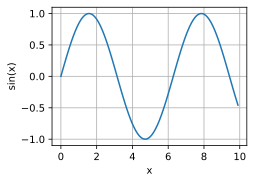

In [ ]:
# 解决 numpy 版本冲突并安装 d2l
!pip install numpy matplotlib pandas requests
!pip install d2l --no-deps

import torch
from d2l import torch as d2l

# 注意力机制（标量版本）


## 代码架构：
1.**数据生成**：需要构造一个带有噪声的非线性函数作为真实世界的数据分布 $y = 2\sin(x) + x^{0.8} + \epsilon$。

2**广播机制 (Broadcasting) 校验**：为了避免低效的 for 循环，我必须利用 PyTorch 的广播机制计算距离矩阵。令查询张量 $\mathbf{Q}$ 的形状为 $(m, 1)$，键张量 $\mathbf{K}$ 的形状为 $(1, n)$，那么 $\mathbf{Q} - \mathbf{K}$ 将自动广播并生成形状为 $(m, n)$ 的距离矩阵。这是整个实现中最具工程美感的一步。

3.**计算图验证**：在带参数的版本中，必须将标量 $w$ 注册为 nn.Parameter，以确保它被纳入 PyTorch 的自动求导（Autograd）引擎中，从而在反向传播时计算梯度。

## 准备数据

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

n_train=50
x_train,_=torch.sort(torch.rand(n_train)*5)
def f(x):
  return torch.sin(x)+x**2
y_train=f(x_train)+torch.normal(0.0,0.5,(n_train,))
x_test=torch.arange(0,5,0.1)
y_truth=f(x_test)

print(f"查询张量：x_test,形状:{x_test.shape}")
print(f"键张量:x_train,形状:{x_train.shape}")
print(f"值张量:y_train,形状:{y_train.shape}")


查询张量：x_test,形状:torch.Size([50])
键张量:x_train,形状:torch.Size([50])
值张量:y_train,形状:torch.Size([50])


## 非参数汇聚

In [2]:
queries=x_test.reshape(-1,1)
keys=x_train.reshape(1,-1)
values=y_train.reshape(-1,1)

dist=(queries-keys)**2
attention_weights=nn.functional.softmax(-dist/2,dim=1)
y_hat_non_param=torch.matmul(attention_weights,values)

print(f"距离矩阵 dist 形状：{dist.shape}")
print(f"注意力权重 attention_weights 形状：{attention_weights.shape}")
print(f"非参数预测输出 y_hat_non_param 形状：{y_hat_non_param.shape}")

距离矩阵 dist 形状：torch.Size([50, 50])
注意力权重 attention_weights 形状：torch.Size([50, 50])
非参数预测输出 y_hat_non_param 形状：torch.Size([50, 1])


## 带参数的注意力汇聚

In [ ]:
class NWKernel(nn.Module):
  def __init__(self,**kwargs):
    super(NWKernel,self).__init__(**kwargs)
    self.w=nn.Parameter(torch.rand((1,)),requires_grad=True)
  def forward(self,x_test,x_train,y_train):
    queries=x_test.reshape(-1,1)
    keys=x_train.reshape(1,-1)
    dist=((queries-keys)*self.w)**2
    self.attention_weights=nn.functional.softmax(-dist/2,dim=1)
    return torch.matmul(self.attention_weights,y_train.reshape(-1,1))
net=NWKernel()
loss_fn=nn.MSELoss(reduction='none') #什么意思？？？
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

print("开始训练！")
for epoch in range(15):
  trainer.zero_grad()
  y_hat=net(x_train,x_train,y_train)
  l=loss_fn(y_hat,y_train.reshape(-1,1))
  l.mean().backward()
  trainer.step()
  print(f"Epoch: {epoch+1},Loss: {l.sum().item():.4f},学习到的 w:{net.w.mean()}")
y_hat_param=net(x_test,x_train,y_train)


开始训练！
Epoch: 1,Loss: 718.6914,学习到的 w:4.783174514770508
Epoch: 2,Loss: 10.2389,学习到的 w:4.785311222076416
Epoch: 3,Loss: 10.2367,学习到的 w:4.787446975708008
Epoch: 4,Loss: 10.2344,学习到的 w:4.789581775665283
Epoch: 5,Loss: 10.2321,学习到的 w:4.791715621948242
Epoch: 6,Loss: 10.2298,学习到的 w:4.793848514556885
Epoch: 7,Loss: 10.2275,学习到的 w:4.795980930328369
Epoch: 8,Loss: 10.2253,学习到的 w:4.798112392425537
Epoch: 9,Loss: 10.2230,学习到的 w:4.800242900848389
Epoch: 10,Loss: 10.2207,学习到的 w:4.802372455596924
Epoch: 11,Loss: 10.2185,学习到的 w:4.804501056671143
Epoch: 12,Loss: 10.2162,学习到的 w:4.806628704071045
Epoch: 13,Loss: 10.2139,学习到的 w:4.808755874633789
Epoch: 14,Loss: 10.2117,学习到的 w:4.810882091522217
Epoch: 15,Loss: 10.2094,学习到的 w:4.813007354736328


## 可视化

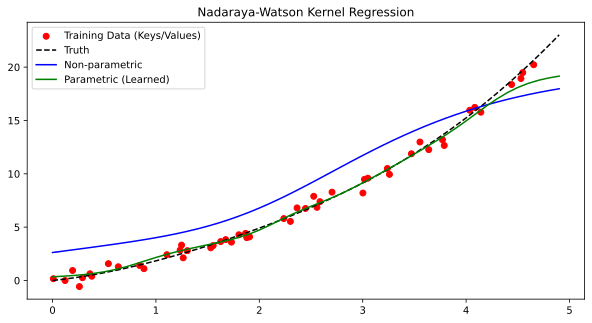

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(x_train.numpy(), y_train.numpy(), c='red', label='Training Data (Keys/Values)')
plt.plot(x_test.numpy(), y_truth.numpy(), c='black', linestyle='--', label='Truth')
plt.plot(x_test.numpy(), y_hat_non_param.numpy(), c='blue', label='Non-parametric')
plt.plot(x_test.numpy(), y_hat_param.detach().numpy(), c='green', label='Parametric (Learned)')
plt.legend()
plt.title("Nadaraya-Watson Kernel Regression")
plt.show()

## 总结

### 拟合曲线震荡问题：
问题在于梯度太大，选择了比较剧烈的函数x**2，并且对loss求的是sum而不是mean

进而导致了w过大，放大了数据之间的差异，经过softmax之后，近似成one_hot了，进而使得距离最近的点获得近似1的概率，其他近似0，然后loss对w的导数近似为0，使得w几乎不变，维持在一个比较高的位置上

### AI的总结：
📐 一步步详细推导：从梯度爆炸到死亡陷阱第一阶段：50 倍的无影脚 (梯度爆炸)在您的代码中，输入了 $n=50$ 个样本。当 reduction='none' 时，损失 $\mathbf{l}$ 是一个包含 50 个误差的向量。

* 当您使用 .sum() 时：目标函数变成了 $L_{sum} = \sum_{i=1}^{50} l_i$。根据微积分的加法法则，它对 $w$ 的梯度为：$\nabla_w L_{sum} = \sum_{i=1}^{50} \nabla_w l_i$。

* 当您使用 .mean() 时：目标函数变成了 $L_{mean} = \frac{1}{50} \sum_{i=1}^{50} l_i$。它的梯度为：$\nabla_w L_{mean} = \frac{1}{50} \sum_{i=1}^{50} \nabla_w l_i$。

物理意义：在使用 .sum() 时，即使您的学习率 $\eta$ 已经设定得比较小（$0.01$），但由于梯度的尺度被无情放大了 $50$ 倍，导致优化器在第一步迈出的步伐 $\Delta w = \eta \cdot \nabla_w L_{sum}$ 变得极其巨大！这就好比一脚油门把参数 $w$ 踹飞到了 $24.86$。

第二阶段：进入黑洞 (梯度消失与卡死)这是最神奇，也是最绝望的地方。为什么 $w$ 飞到 25 之后，模型就不再修正自己了，而是永远在那抖动？

让我们回到注意力权重的计算核心——Softmax 函数：

$$\alpha(x_i) = \text{softmax}(-\frac{1}{2}((x - x_i)w)^2)$$

* 极端的距离放大：当 $w \approx 25$ 时，$w^2 \approx 625$。这意味着，原本 $x$ 和 $x_i$ 之间极其微小的差距（比如 $0.1$），经过平方和 $w^2$ 放大后，差距会被拉大到数百倍。

* 绝对的赢家通吃：Softmax 的特性是“强者愈强”。当输入数值差距极大时，Softmax 会输出一个近似的 One-hot 向量（距离最近的那个点获得无限接近 $1.0$ 的概率，其余所有点获得无限接近 $0.0$ 的概率）。

* 梯度的死亡：在数学上，Softmax 函数输出概率 $p_i$ 的导数中，包含着 $p_i(1 - p_i)$ 这个核心项。

 * 如果您算出的概率 $p_i \to 1.0$，那么 $p_i(1 - p_i) \to 0$。

  * 如果您算出的概率 $p_i \to 0.0$，那么 $p_i(1 - p_i) \to 0$。
  
**终极结论**：梯度爆炸把 $w$ 扔进了一个 Softmax 的“死亡饱和区”。在这个区域里，任何微小的 $w$ 变动都无法改变“赢家通吃”的局面，导致 Loss 对 $w$ 的导数彻底变成了 $0$。引擎熄火，网络脑死亡，这就是您看到的——参数永远停在 $24.87$，曲线像锯齿一样抖动。

# New Section
## 注意力评分

# 过渡+引入

##验证与升维重构过程(Verification & Dimensional Upgrade Process)

**当前进度锚点**：我们刚刚在 Colab 中用极其底层的张量推演，完美降伏了一维空间下的 Nadaraya-Watson 核回归（非参数与带参数模型），并解决了由 sum() 引发的梯度爆炸问题。


**物理瓶颈突破** (Rethinking the Dimension)：NW 核回归虽然精妙，但它只能处理标量 (Scalar)（即 $x$ 和 $x_i$ 都是单个数字）。在真实的自然语言处理（NLP）和计算机视觉（CV）任务中，一个词（如“苹果”）或一个图像块，会被编码成一个几百维的稠密向量 (Dense Vector)。

**推导策略升维**：如果 Query 和 Key 变成了高维向量（甚至维度都不一样），我们还能简单地用 $(q-k)^2$ 来算距离吗？不行。我需要为您引入现代 Transformer 架构的真正基石——注意力评分函数 (Attention Scoring Functions)。我们将用严密的线性代数，推导高维空间中“加性注意力”和“缩放点积注意力”的张量流转。

# 升高维度
* 查询 (Query)：$\mathbf{q} \in \mathbb{R}^q$（例如，解码器当前时刻的 256 维隐藏状态）

* 键 (Key)：$\mathbf{k} \in \mathbb{R}^k$（例如，编码器某一时刻的 512 维隐藏状态）

* 值 (Value)：$\mathbf{v} \in \mathbb{R}^v$

我们的终极目标依然没变：计算 $\mathbf{q}$ 和 $\mathbf{k}$ 之间的注意力分数 $a(\mathbf{q}, \mathbf{k})$，然后经过 Softmax 变成概率，最后去加权 $\mathbf{v}$。

## 加性注意力

* 投影与融合：定义权重矩阵 $\mathbf{W}_q \in \mathbb{R}^{h \times q}$ 和 $\mathbf{W}_k \in \mathbb{R}^{h \times k}$。将它们投影到统一的维度 $h$，相加后通过 $\text{tanh}$ 激活：$$\mathbf{x}_{fusion} = \text{tanh}(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k})$$此时，$\mathbf{x}_{fusion} \in \mathbb{R}^{h}$。

* 降维打分：这正是您之前精准察觉到那个“假 $v$”。我们引入一个权重向量 $\mathbf{w}_v \in \mathbb{R}^{h}$，与融合特征进行点积，将其压缩为标量分数：$$a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \mathbf{x}_{fusion}$$

### 广播机制的讲解

从输出可以看出，通过 `unsqueeze` 操作，我们巧妙地引入了维度为1的轴，使得两个张量在相加时能够触发广播机制。最终的 `features` 张量形状 `(B, num_queries, num_keys, h)` 确保了 `queries` 中的每个查询都与 `keys` 中的每个键进行了对应的特征维度的相加，而无需显式的循环，这在计算上非常高效。

In [ ]:
import torch

# 假设批量大小 B=2, 查询数量 num_queries=3, 键数量 num_keys=4, 特征维度 h=5

# 原始 queries 张量形状: (B, num_queries, h)
queries = torch.randn(2, 3, 5)
print(f"原始 queries 形状: {queries.shape}")
print('\n')
print(f"{queries}")

# 原始 keys 张量形状: (B, num_keys, h)
keys = torch.randn(2, 4, 5)
print(f"原始 keys 形状: {keys.shape}")
print('\n')
print(f"{keys}")

# 1. 对 queries 进行 unsqueeze(2) 操作
# 形状变为 (B, num_queries, 1, h)
queries_reshaped = queries.unsqueeze(2)
print(f"queries.unsqueeze(2) 后的形状: {queries_reshaped.shape}")
print('\n')
print(f"{queries_reshaped}")

# 2. 对 keys 进行 unsqueeze(1) 操作
# 形状变为 (B, 1, num_keys, h)
keys_reshaped = keys.unsqueeze(1)
print(f"keys.unsqueeze(1) 后的形状: {keys_reshaped.shape}")
print('\n')
print(f"{keys_reshaped}")

# 3. 执行广播相加
# PyTorch 会自动扩展维度 1 来匹配另一个张量的大小
features = queries_reshaped + keys_reshaped
print(f"广播相加后 features 的形状: {features.shape}")
print('\n')
print(f"{features}")

# 验证维度：
# B: 2 vs 2 -> 2
# num_queries: 3 vs 1 -> 3
# num_keys: 1 vs 4 -> 4
# h: 5 vs 5 -> 5
# 最终形状 (2, 3, 4, 5) 正如预期。

原始 queries 形状: torch.Size([2, 3, 5])


tensor([[[ 1.4579, -0.1254,  0.1767, -0.2574, -0.8225],
         [ 1.9306, -1.0495, -0.0969, -0.9805,  0.3128],
         [-1.2639,  1.4366,  0.3039, -0.4178,  1.4435]],

        [[ 1.3058,  0.9518,  0.7319, -1.6383,  0.7672],
         [ 2.2600, -1.4433,  0.4937, -0.4667, -0.2360],
         [-0.9452, -0.0466,  1.9859,  0.6422,  1.6364]]])
原始 keys 形状: torch.Size([2, 4, 5])


tensor([[[-0.0400,  0.7053, -1.7111,  0.0819,  1.0431],
         [ 0.4706, -1.5602, -1.8449, -0.0841,  0.4252],
         [-0.7721, -1.4490, -0.7506,  0.0937, -0.6629],
         [ 1.1967,  0.0766, -0.9936, -0.2479,  0.4327]],

        [[-0.5407, -2.2941, -0.8375, -0.7989, -0.0219],
         [-0.7469,  2.6118, -0.2655,  0.5822, -0.9452],
         [ 0.1626, -0.4769, -0.0272, -0.2454, -0.9183],
         [ 0.2333, -0.6223,  0.8718,  0.9822,  0.2301]]])
queries.unsqueeze(2) 后的形状: torch.Size([2, 3, 1, 5])


tensor([[[[ 1.4579, -0.1254,  0.1767, -0.2574, -0.8225]],

         [[ 1.9306, 

In [ ]:
import math
import torch
from torch import nn
class AdditiveAttention(nn.Module):
  def __init__(self,key_size,query_size,num_hiddens,dropout,**kwargs):
    super(AdditiveAttention,self).__init__(**kwargs)
    self.W_q=nn.Linear(query_size,num_hiddens,bias=False)
    self.W_k=nn.Linear(key_size,num_hiddens,bias=False)
    self.W_v=nn.Linear(num_hiddens,1,bias=False)
    self.dropout=nn.Dropout(dropout)

  def forward(self,queries,keys,values, valid_lens): # Added valid_lens
    #queries [B,num_queries,queries_size]
    #keys [B,num_keys,keys_size]

    queries,keys=self.W_q(queries),self.W_k(keys)
    # queries->[B,num_queries,h]
    # keys->[B,num_keys,h]

    # queries -->[B,num_queries,1,h]
    # keys -->[B,1,num_keys,h]

    features=queries.unsqueeze(2)+keys.unsqueeze(1)
    features=torch.tanh(features)
    scores=self.W_v(features).squeeze(-1)
    self.attention_weights=masked_softmax(scores,valid_lens) # Used masked_softmax
    return torch.bmm(self.dropout(self.attention_weights),values)

### 难点
在于张量的运算，在定义神经层的时候，理解成单样本
在传播的时候，要展开写
熟练掌握张量的广播机制

## 缩放点积注意力

当 $q = k = d$ 时，最暴力、最符合底层硬件胃口（CUDA 矩阵乘法）的方法就是直接求向量点积。

**数学推导**：直接计算 $\mathbf{q}^\top \mathbf{k}$。但高维空间有一个致命问题：如果维度 $d$ 很大（比如 512），点积出来的数值也会随之变得极大或极小。这会再次导致我们在 NW 核回归中见识过的**“Softmax 死亡饱和区”**，导致梯度消失。


为了解决这个问题，我们必须强行用 $\sqrt{d}$ 将方差拉回 $1$：$$a(\mathbf{q}, \mathbf{k}) = \frac{\mathbf{q}^\top \mathbf{k}}{\sqrt{d}}$$

In [ ]:
import math
import torch
from torch import nn
class DotProductAttention(nn.Module):
  def __init__(self,dropout,**kwargs):
    super(DotProductAttention,self).__init__(**kwargs)
    self.dropout=nn.Dropout(dropout)
  def forward(self,queries,keys,values):
    # queries [B,num_queries,d]
    # keys [B,num_keys,d]
    d=queries.shape[-1]
    scores=torch.bmm(queries,keys.transpose(1,2)) / math.sqrt(d)
    self.attention_weights=nn.functional.softmax(scores,dim=-1)

    #values [B,num_keys,v]
    #attention_weights [B,num_queries,num_keys]
    return torch.bmm(self.dropout(self.attention_weights),values)




# New Section

# seq2seq


In [ ]:
import collections
import torch
from torch.utils.data import TensorDataset, DataLoader

class Vocab:
    """Seq2Seq 专用的文本词表（支持特殊控制符）"""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []

        # 1. 展开所有句子并统计词频
        counter = collections.Counter([token for line in tokens for token in line])
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)

        # 2. 初始化核心映射表，<unk> (未知词) 的索引永远为 0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        # 3. 按频率将词汇填入映射表
        for token, freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        # 如果传入的是单个词，返回其索引；如果是序列，递归返回索引列表
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.token_to_idx['<unk>'])
        return [self.__getitem__(token) for token in tokens]


def truncate_pad(line, num_steps, padding_token):
    """截断或填充文本序列至固定长度 (num_steps)"""
    if len(line) > num_steps:
        return line[:num_steps]  # 句子过长，无情截断
    # 句子太短，用 <pad> 补齐
    return line + [padding_token] * (num_steps - len(line))


def build_array_nmt(lines, vocab, num_steps):
    """将文本序列转换为可训练的小批量张量，并记录有效长度"""
    # 将文本转换为数字索引
    lines = [vocab[l] for l in lines]
    # 每个序列末尾强行追加一个 <eos> (End of Sequence) 标识符
    lines = [l + [vocab['<eos>']] for l in lines]

    # 记录张量填充前的“真实有效长度”
    valid_len = torch.tensor([len(l) for l in lines])

    # 统一将所有句子对齐到 num_steps 长度
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    return array, valid_len


def load_data_toy_nmt(batch_size, num_steps):
    """构建用于跑通测试的迷你英-法数据集"""
    # 极简语料库 (英语 -> 法语)
    text_data = [
        ("they are watching .", "ils regardent ."),
        ("i am eating .", "je mange ."),
        ("he is sleeping .", "il dort ."),
        ("we are playing .", "nous jouons ."),
        ("she is running .", "elle court ."),
        ("hello .", "bonjour .")
    ] * 20  # 人为复制20遍，扩充数据量以便观察模型收敛

    # 解包并按空格分词
    source, target = zip(*text_data)
    src_tokens = [s.split(' ') for s in source]
    tgt_tokens = [t.split(' ') for t in target]

    # 初始化包含 Seq2Seq 必需特殊字符的词表
    reserved_tokens = ['<pad>', '<bos>', '<eos>']
    src_vocab = Vocab(src_tokens, reserved_tokens=reserved_tokens)
    tgt_vocab = Vocab(tgt_tokens, reserved_tokens=reserved_tokens)

    # 转化为对齐后的张量与有效长度信息
    src_array, src_valid_len = build_array_nmt(src_tokens, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(tgt_tokens, tgt_vocab, num_steps)

    # 使用 PyTorch 原生的 TensorDataset 和 DataLoader 进行批次化与打乱
    dataset = TensorDataset(src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = DataLoader(dataset, batch_size, shuffle=True)

    return data_iter, src_vocab, tgt_vocab

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

def sequence_mask(X, valid_len, value=0):
    """在序列中掩蔽不相关的项"""
    maxlen = X.size(1)
    # 利用广播机制生成掩码矩阵
    mask = torch.arange((maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X

def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    if valid_lens is None:
        return F.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 强行将超出有效长度的值设为一个极大的负数 (-1e6)
        # 这样经过 softmax 后，对应的权重就会无限趋近于 0
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return F.softmax(X.reshape(shape), dim=-1)

In [ ]:
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super(Seq2SeqEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 默认 batch_first=False，这里显式说明便于理解
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout)

    def forward(self, X, *args):
        # X 形状: (batch_size, num_steps)
        X = self.embedding(X) # 变为 (batch_size, num_steps, embed_size)
        X = X.permute(1, 0, 2) # RNN 需要 (num_steps, batch_size, embed_size)

        # output: 所有时间步的顶层隐藏状态 (num_steps, batch_size, num_hiddens)
        # state: 最后一个时间步的所有层隐藏状态 (num_layers, batch_size, num_hiddens)
        output, state = self.rnn(X)
        return output, state

In [ ]:
class Seq2SeqAttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super(Seq2SeqAttentionDecoder, self).__init__()
        # 定义注意力层
        self.attention = AdditiveAttention(num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # 核心变化：RNN的输入维度变成了 (嵌入维度 + 注意力上下文维度)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens):
        outputs, hidden_state = enc_outputs
        # 将 outputs 转置为 batch_first，方便 attention 计算
        # 形状变为: (batch_size, num_steps, num_hiddens)
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state

        # X 形状: (batch_size, num_steps)
        X = self.embedding(X).permute(1, 0, 2) # (num_steps, batch_size, embed_size)

        outputs, self._attention_weights = [], []

        # 按时间步循环展开解码过程
        for x in X:
            # query 提取解码器 RNN 最顶层的隐状态
            # hidden_state[-1] 形状: (batch_size, num_hiddens)
            # query 形状: (batch_size, 1, num_hiddens)
            query = hidden_state[-1].unsqueeze(1)

            # 计算当前时刻的上下文向量
            # context 形状: (batch_size, 1, num_hiddens)
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)

            # 将上下文向量与当前时刻的输入词嵌入在特征维度拼接
            # x 本身是 (batch_size, embed_size) -> unsqueeze -> (batch_size, 1, embed_size)
            # x_and_context 形状: (batch_size, 1, embed_size + num_hiddens)
            x_and_context = torch.cat((context, x.unsqueeze(1)), dim=-1)

            # 喂入 RNN 步进一次
            # 输入需要转回 (num_steps=1, batch_size, features)
            out, hidden_state = self.rnn(x_and_context.permute(1, 0, 2), hidden_state)

            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)

        # 循环结束，拼接所有时间步的输出
        # outputs 形状: (num_steps, batch_size, num_hiddens)
        outputs = torch.cat(outputs, dim=0)

        # 经过全连接层映射到词表大小
        outputs = self.dense(outputs)

        # 转置回标准输出形状: (batch_size, num_steps, vocab_size)
        return outputs.permute(1, 0, 2), [enc_outputs, hidden_state, enc_valid_lens]

In [ ]:
import torch
from torch import nn

def xavier_init_weights(m):
    """Xavier 初始化权重，防止训练初期梯度消失或爆炸"""
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
    if type(m) == nn.GRU:
        for param in m._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(m._parameters[param])

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练 Seq2Seq 模型"""
    # 1. 初始化模型并移至对应硬件
    net.apply(xavier_init_weights)
    net.to(device)

    # 2. 定义优化器和我们写好的掩码损失函数
    # Seq2Seq 任务中，Adam 优化器在面对复杂高维空间时收敛效果通常优于纯 SGD
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()

    for epoch in range(num_epochs):
        total_loss = 0.0
        total_tokens = 0

        for batch in data_iter:
            optimizer.zero_grad()
            # 假设你的 DataLoader 返回四个元素:
            # 源序列 X, 源有效长度 X_valid_len, 目标序列 Y, 目标有效长度 Y_valid_len
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]

            # ---------------------------------------------------------
            # 核心机制：Teacher Forcing 的张量偏移逻辑
            # ---------------------------------------------------------
            # 获取 <bos> (Begin of Sequence) 在词表中的索引
            bos_idx = tgt_vocab['<bos>']
            # 构造一个形状为 (batch_size, 1) 的全 <bos> 矩阵
            bos_tensor = torch.tensor([bos_idx] * Y.shape[0], device=device).reshape(-1, 1)

            # Y[:, :-1] 切掉了原句的最后一个词
            # torch.cat 将 <bos> 拼在头部，完美实现了序列整体向右平移一步
            dec_input = torch.cat([bos_tensor, Y[:, :-1]], dim=1)

            # 前向传播 (注意将 X_valid_len 传入用于 Encoder 的填充掩码，如果你的编码器实现了的话)
            Y_hat, _ = net(X, dec_input, X_valid_len)

            # 计算掩码损失 (屏蔽掉原本为了对齐而补充的 <pad> 的损失)
            l = loss(Y_hat, Y, Y_valid_len)

            # 反向传播与梯度裁剪
            l.sum().backward() # 这里用 sum 是因为 MaskedSoftmaxCELoss 内部已经算过句子的 mean 了

            # 梯度裁剪：防止 RNN 展开时梯度爆炸 (使用你之前定义的函数)
            grad_clipping(net, 1)
            optimizer.step()

            # 记录数据用于打印
            with torch.no_grad():
                total_loss += l.sum().item()
                total_tokens += Y_valid_len.sum().item()

        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch + 1:3d}, Loss: {total_loss / total_tokens:.4f}')

In [ ]:
import torch
from torch import nn

# ==========================================
# 第一部分：补齐运行依赖模块 (防止 NameError)
# ==========================================

# 1. 硬件设备定义
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 梯度裁剪函数 (train_seq2seq 中调用了此函数)
def grad_clipping(net, theta):
    """裁剪梯度，防止 RNN 训练初期梯度爆炸"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net
    # 使用 PyTorch 内置的梯度裁剪函数
    torch.nn.utils.clip_grad_norm_(params, theta)

# 3. 带掩码的损失函数
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带遮蔽的 softmax 交叉熵损失函数"""
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction = 'none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

# 4. 模型外壳包装
class EncoderDecoder(nn.Module):
    """编码器-解码器架构的基类"""
    def __init__(self, encoder, decoder, **kwargs):
        super(EncoderDecoder, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, enc_valid_lens):
        enc_outputs = self.encoder(enc_X, enc_valid_lens)
        dec_state = self.decoder.init_state(enc_outputs, enc_valid_lens)
        return self.decoder(dec_X, dec_state)

# 5. 序列预测函数
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps, device):
    """序列到序列模型的预测 (贪心解码)"""
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens = src_tokens + [src_vocab['<pad>']] * (num_steps - len(src_tokens))
    enc_X = torch.unsqueeze(torch.tensor(src_tokens, dtype=torch.long, device=device), dim=0)
    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    dec_X = torch.unsqueeze(torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device), dim=0)

    output_seq = []
    for _ in range(num_steps):
        Y_hat, dec_state = net.decoder(dec_X, dec_state)
        pred = Y_hat.argmax(dim=2)
        pred_idx = pred.squeeze(dim=0).type(torch.int32).item()
        if pred_idx == tgt_vocab['<eos>']:
            break
        output_seq.append(pred_idx)
        dec_X = pred
    return ' '.join(tgt_vocab.idx_to_token[idx] for idx in output_seq)

# ==========================================
# 第二部分：执行实例化与模型训练测试
# ==========================================

# 1. 超参数设定
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs = 0.005, 300  # 增加了 Epoch，确保小语料集能完全收敛

# 2. 构建数据迭代器与词表 (调用你在 Cell 11 写的函数)
train_iter, src_vocab, tgt_vocab = load_data_toy_nmt(batch_size, num_steps)

# 3. 实例化网络架构
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

# 4. 启动训练
print(f"✅ 开始在 {device} 上训练模型...")
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

# 5. 实战预测测试
print("\n🎉 --- 翻译测试 ---")
test_sentences = [
    "they are watching .",
    "i am eating .",
    "he is sleeping ."
]

for sentence in test_sentences:
    translation = predict_seq2seq(net, sentence, src_vocab, tgt_vocab, num_steps, device)
    print(f'输入: {sentence:<20} => 预测翻译结果: {translation}')

✅ 开始在 cpu 上训练模型...
Epoch  50, Loss: 0.0001
Epoch 100, Loss: 0.0000
Epoch 150, Loss: 0.0000
Epoch 200, Loss: 0.0000
Epoch 250, Loss: 0.0000
Epoch 300, Loss: 0.0000

🎉 --- 翻译测试 ---
输入: they are watching .  => 预测翻译结果: ils regardent .
输入: i am eating .        => 预测翻译结果: je mange .
输入: he is sleeping .     => 预测翻译结果: il dort .


# 多头注意力


## 逻辑推导

📐 逻辑推导：从“单打独斗”到“团队合作”在代码实现前，我们需要明确张量维度的流转逻辑：

**线性投影**：将查询 ($Q$)、键 ($K$)、值 ($V$) 分别通过三组学习好的线性层，投影到低维。

**拆分 (Split)**：将投影后的维度 $d_{model}$ 拆分成 $h$ 个头，每个头的维度为 $d_k = d_{model} / h$。并行计算：对这 $h$ 个头并行执行缩放点积注意力。

**拼接 (Concat)**：将所有头的输出拼接回原来的维度 $d_{model}$。

**最后投影**：通过一个最终的线性层进行特征融合。$$\text{MultiHead}(Q, K, V) = \text{Concat}(head_1, \dots, head_h)W^O$$

In [ ]:
import torch
from torch import nn
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        # 使用你之前学过的缩放点积注意力作为底层驱动
        self.attention = d2l.DotProductAttention(dropout)

        # 定义四个线性层：Wq, Wk, Wv 以及最后的输出层 Wo
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # 1. 线性投影并变形：(batch_size, 查询/键值个数, num_hiddens)
        # 2. 准备并行计算：将 num_hiddens 拆分为 num_heads 个头
        # 变换后的形状: (batch_size * num_heads, 查询/键值个数, num_hiddens / num_heads)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            # 在多头模式下，我们需要对有效长度进行重复，以匹配 (batch_size * num_heads)
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # 3. 在所有头中并行执行注意力汇聚
        # output 形状: (batch_size * num_heads, 查询个数, num_hiddens / num_heads)
        output = self.attention(queries, keys, values, valid_lens)

        # 4. 逆向变形：将多个头拼接回原来的 num_hiddens 维度
        # output_concat 形状: (batch_size, 查询个数, num_hiddens)
        output_concat = transpose_output(output, self.num_heads)

        # 5. 最后一次线性融合
        return self.W_o(output_concat)

# --- 辅助函数：处理多头的张量变形 ---

def transpose_qkv(X, num_heads):
    """将形状从 (batch_size, 查询个数, num_hiddens)
    变换为 (batch_size * num_heads, 查询个数, num_hiddens / num_heads)"""
    # X 形状: (batch_size, 查询个数, num_heads, num_hiddens / num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    # 交换维度变为: (batch_size, num_heads, 查询个数, num_hiddens / num_heads)
    X = X.permute(0, 2, 1, 3)
    # 最终拼接前两个维度，方便矩阵乘法
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    """逆转 transpose_qkv 的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

# New Section